 - by **Nabankur Ray**

# **BUSINESS CONTEXT**

BCCI has hired an external analytics consulting firm for data analytics. The major objective of this tie up is to extract actionable insights from the historical match data and make strategic changes to make India win. Primary objective is to create Machine Learning models which correctly predicts a win for the Indian Cricket Team. Once a model is developed then you have to extract actionable insights and recommendation.

Also, below are the details of the next 10 matches, India is going to play. You have to predict the result of the matches and if you are getting prediction as a Loss then suggest some changes and re-run your model again until you are getting Win as a prediction. You cannot use the same strategy in the entire series, because opponent will get to know your strategy and they can come with counter strategy. Hence for all the below 5 matches you have to suggest unique strategies to make India win. The suggestions should be in-line with the variables that have been mentioned in the given data set. Do consider the feasibility of the suggestions very carefully as well.

1. 1 Test match with England in England. All the match are day matches. In England, it will be rainy season at the time to match.

2. 2 T20 match with Australia in India. All the match are Day and Night matches. In India, it will be winter season at the time to match.

3. 2 ODI match with Sri Lanka in India. All the match are Day and Night matches. In India, it will be winter season at the time to match.


# **Data Overview**

In [ ]:
# Libraries to help with reading and manipulating data
import pandas as pd
import numpy as np

# To suppress scientific notations
pd.set_option("display.float_format", lambda x: "%.3f" % x)

# Libaries to help with data visualization
import matplotlib.pyplot as plt
import seaborn as sns

In [ ]:
# To supress warnings
import warnings
warnings.filterwarnings("ignore")

In [ ]:
# Loading the data from drive
from google.colab import drive
drive.mount('/content/drive/')
data = pd.read_excel('/content/drive/My Drive/Sports Data.xlsx')
data.head()

Drive already mounted at /content/drive/; to attempt to forcibly remount, call drive.mount("/content/drive/", force_remount=True).


,Game_number,Result,Avg_team_Age,Match_light_type,Match_format,Bowlers_in_team,Wicket_keeper_in_team,All_rounder_in_team,First_selection,Opponent,...,Max_run_scored_1over,Max_wicket_taken_1over,Extra_bowls_bowled,Min_run_given_1over,Min_run_scored_1over,Max_run_given_1over,extra_bowls_opponent,player_highest_run,Players_scored_zero,player_highest_wicket
0,Game_1,Loss,18.000,Day,ODI,3.000,1,3.000,Bowling,Srilanka,...,13.000,3,0.000,2,3.000,6.000,0,54.000,3,1
1,Game_2,Win,24.000,Day,T20,3.000,1,4.000,Batting,Zimbabwe,...,12.000,1,0.000,0,3.000,6.000,0,69.000,2,1
2,Game_3,Loss,24.000,Day and Night,T20,3.000,1,2.000,Bowling,Zimbabwe,...,14.000,4,0.000,0,3.000,6.000,0,69.000,3,1
3,Game_4,Win,24.000,NaN,ODI,2.000,1,2.000,Bowling,Kenya,...,15.000,4,0.000,2,3.000,6.000,0,73.000,3,1
4,Game_5,Loss,24.000,Night,ODI,1.000,1,3.000,Bowling,Srilanka,...,12.000,4,0.000,0,3.000,6.000,0,80.000,3,1


## Understanding the Given Dataset

In [ ]:
# viewing the first 5 rows of the data
data.head()

,Game_number,Result,Avg_team_Age,Match_light_type,Match_format,Bowlers_in_team,Wicket_keeper_in_team,All_rounder_in_team,First_selection,Opponent,...,Max_run_scored_1over,Max_wicket_taken_1over,Extra_bowls_bowled,Min_run_given_1over,Min_run_scored_1over,Max_run_given_1over,extra_bowls_opponent,player_highest_run,Players_scored_zero,player_highest_wicket
0,Game_1,Loss,18.000,Day,ODI,3.000,1,3.000,Bowling,Srilanka,...,13.000,3,0.000,2,3.000,6.000,0,54.000,3,1
1,Game_2,Win,24.000,Day,T20,3.000,1,4.000,Batting,Zimbabwe,...,12.000,1,0.000,0,3.000,6.000,0,69.000,2,1
2,Game_3,Loss,24.000,Day and Night,T20,3.000,1,2.000,Bowling,Zimbabwe,...,14.000,4,0.000,0,3.000,6.000,0,69.000,3,1
3,Game_4,Win,24.000,NaN,ODI,2.000,1,2.000,Bowling,Kenya,...,15.000,4,0.000,2,3.000,6.000,0,73.000,3,1
4,Game_5,Loss,24.000,Night,ODI,1.000,1,3.000,Bowling,Srilanka,...,12.000,4,0.000,0,3.000,6.000,0,80.000,3,1


In [ ]:
# viewing the last 5 rows of the data
data.tail()

,Game_number,Result,Avg_team_Age,Match_light_type,Match_format,Bowlers_in_team,Wicket_keeper_in_team,All_rounder_in_team,First_selection,Opponent,...,Max_run_scored_1over,Max_wicket_taken_1over,Extra_bowls_bowled,Min_run_given_1over,Min_run_scored_1over,Max_run_given_1over,extra_bowls_opponent,player_highest_run,Players_scored_zero,player_highest_wicket
2925,Game_2926,Win,30.000,Day,T20,3.000,1,4.000,Batting,South Africa,...,15.000,3,8.000,0,3.000,6.000,3,50.000,3,2
2926,Game_2927,Win,30.000,Day,ODI,4.000,1,3.000,Bowling,Kenya,...,14.000,4,8.000,2,3.000,6.000,2,52.000,2,1
2927,Game_2928,Win,30.000,Day and Night,ODI,4.000,1,3.000,Bowling,Pakistan,...,14.000,4,10.000,2,4.000,10.000,2,80.000,3,2
2928,Game_2929,Win,30.000,Day,ODI,4.000,1,3.000,Batting,Kenya,...,14.000,2,20.000,2,3.000,6.000,3,98.000,3,1
2929,Game_2930,Win,30.000,Day,ODI,4.000,1,3.000,Batting,Kenya,...,12.000,4,4.000,5,3.000,6.000,3,62.000,1,1


In [ ]:
# Checking the shape of the data
data.shape

(2930, 23)

* There are **2930 rows** and **23 Columns** are present in the given datasets.

### Checking the data types of the columns for the dataset

In [ ]:
# Checking the structure and data type of the given data
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2930 entries, 0 to 2929
Data columns (total 23 columns):
 #   Column                  Non-Null Count  Dtype  
---  ------                  --------------  -----  
 0   Game_number             2930 non-null   object 
 1   Result                  2930 non-null   object 
 2   Avg_team_Age            2833 non-null   float64
 3   Match_light_type        2878 non-null   object 
 4   Match_format            2860 non-null   object 
 5   Bowlers_in_team         2848 non-null   float64
 6   Wicket_keeper_in_team   2930 non-null   int64  
 7   All_rounder_in_team     2890 non-null   float64
 8   First_selection         2871 non-null   object 
 9   Opponent                2894 non-null   object 
 10  Season                  2868 non-null   object 
 11  Audience_number         2849 non-null   float64
 12  Offshore                2866 non-null   object 
 13  Max_run_scored_1over    2902 non-null   float64
 14  Max_wicket_taken_1over  2930 non-null   

* It can be observed that some columns have less entries (less than 2930 rows) which indicates that there are no missing values in the given dataset.

* There are attributes of different types (int, float, object) in the data.

* There are 13 numerical columns in the data and 10 categorical columns.

### Statistical summary of the dataset

In [ ]:
# Numerical summary statistics
data.describe().T

,count,mean,std,min,25%,50%,75%,max
Avg_team_Age,2833.000,29.243,2.264,12.000,30.000,30.000,30.000,70.000
Bowlers_in_team,2848.000,2.914,1.024,1.000,2.000,3.000,4.000,5.000
Wicket_keeper_in_team,2930.000,1.000,0.000,1.000,1.000,1.000,1.000,1.000
All_rounder_in_team,2890.000,2.722,1.093,1.000,2.000,3.000,4.000,4.000
Audience_number,2849.000,46267.961,48599.581,7063.000,20363.000,34349.000,57876.000,1399930.000
Max_run_scored_1over,2902.000,15.200,3.661,11.000,12.000,14.000,18.000,25.000
Max_wicket_taken_1over,2930.000,2.714,1.081,1.000,2.000,3.000,4.000,4.000
Extra_bowls_bowled,2901.000,11.253,7.781,0.000,6.000,10.000,15.000,40.000
Min_run_given_1over,2930.000,1.953,1.678,0.000,0.000,2.000,3.000,6.000
Min_run_scored_1over,2903.000,2.763,0.706,1.000,2.000,3.000,3.000,4.000


In [ ]:
# Categorical summary statistics
data.describe(include='object').T

,count,unique,top,freq
Game_number,2930,2930,Game_2930,1
Result,2930,2,Win,2457
Match_light_type,2878,3,Day,2041
Match_format,2860,4,ODI,1865
First_selection,2871,3,Bowling,1722
Opponent,2894,9,South Africa,640
Season,2868,3,Rainy,1309
Offshore,2866,2,No,2057
Players_scored_zero,2930,5,3,1730
player_highest_wicket,2930,6,1,1084


In [ ]:
# checking the number of unique values
data.nunique()

,0
Game_number,2930
Result,2
Avg_team_Age,13
Match_light_type,3
Match_format,4
Bowlers_in_team,5
Wicket_keeper_in_team,1
All_rounder_in_team,4
First_selection,3
Opponent,9


In [ ]:
# Viewing the unique elements in categorical columns
for col in data.select_dtypes(include='object').columns:
  print(f'{col}: {data[col].unique()}')


Game_number: ['Game_1' 'Game_2' 'Game_3' ... 'Game_2928' 'Game_2929' 'Game_2930']
Result: ['Loss' 'Win']
Match_light_type: ['Day' 'Day and Night' nan 'Night']
Match_format: ['ODI' 'T20' 'Test' '20-20' nan]
First_selection: ['Bowling' 'Batting' 'Bat' nan]
Opponent: ['Srilanka' 'Zimbabwe' 'Kenya' 'Australia' 'England' 'South Africa'
 'Pakistan' 'West Indies' 'Bangladesh' nan]
Season: ['Summer' nan 'Winter' 'Rainy']
Offshore: ['No' 'Yes' nan]
Players_scored_zero: [3 2 1 4 'Three']
player_highest_wicket: [1 2 3 4 'Three' 5]


In [ ]:
# Replacing 'Three' to 3 in Players_scored_zero & player_highest_wicket column

data['Players_scored_zero'] = data['Players_scored_zero'].replace('Three', 3)
data['player_highest_wicket'] = data['player_highest_wicket'].replace('Three', 3)


In [ ]:
# Viewing the unique elements in categorical columns
for col in data.select_dtypes(include='object').columns:
  print(f'{col}: {data[col].unique()}')


Game_number: ['Game_1' 'Game_2' 'Game_3' ... 'Game_2928' 'Game_2929' 'Game_2930']
Result: ['Loss' 'Win']
Match_light_type: ['Day' 'Day and Night' nan 'Night']
Match_format: ['ODI' 'T20' 'Test' '20-20' nan]
First_selection: ['Bowling' 'Batting' 'Bat' nan]
Opponent: ['Srilanka' 'Zimbabwe' 'Kenya' 'Australia' 'England' 'South Africa'
 'Pakistan' 'West Indies' 'Bangladesh' nan]
Season: ['Summer' nan 'Winter' 'Rainy']
Offshore: ['No' 'Yes' nan]


In [ ]:
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2930 entries, 0 to 2929
Data columns (total 23 columns):
 #   Column                  Non-Null Count  Dtype  
---  ------                  --------------  -----  
 0   Game_number             2930 non-null   object 
 1   Result                  2930 non-null   object 
 2   Avg_team_Age            2833 non-null   float64
 3   Match_light_type        2878 non-null   object 
 4   Match_format            2860 non-null   object 
 5   Bowlers_in_team         2848 non-null   float64
 6   Wicket_keeper_in_team   2930 non-null   int64  
 7   All_rounder_in_team     2890 non-null   float64
 8   First_selection         2871 non-null   object 
 9   Opponent                2894 non-null   object 
 10  Season                  2868 non-null   object 
 11  Audience_number         2849 non-null   float64
 12  Offshore                2866 non-null   object 
 13  Max_run_scored_1over    2902 non-null   float64
 14  Max_wicket_taken_1over  2930 non-null   

## Checking for Missing/ Duplicate Values

In [ ]:
# checking for the duplicate values
data.duplicated().sum()

np.int64(0)

In [ ]:
# Checking for missing Values
missing_value_count = data.isnull().sum()
missing_value_count_sorted = missing_value_count.sort_values(ascending=False)
missing_value_count_sorted

,0
Avg_team_Age,97
Bowlers_in_team,82
Audience_number,81
Match_format,70
Offshore,64
Season,62
First_selection,59
Match_light_type,52
All_rounder_in_team,40
Opponent,36


In [ ]:
# Calculate the percentage of missing values in each column
missing_percentage = (data.isnull().sum() / len(data)) * 100

# Sort the columns by the percentage of missing values in descending order
missing_percentage_sorted = missing_percentage.sort_values(ascending=False)

# Print the sorted percentage of missing values
missing_percentage_sorted

,0
Avg_team_Age,3.311
Bowlers_in_team,2.799
Audience_number,2.765
Match_format,2.389
Offshore,2.184
Season,2.116
First_selection,2.014
Match_light_type,1.775
All_rounder_in_team,1.365
Opponent,1.229


In [ ]:
# Checking the total number of missing values
total_missing = missing_value_count.sum()

print(f"Total number of missing values: {total_missing}")


Total number of missing values: 789


 But these are fairly low percentages — suitable for mean/mode imputation or row deletion if needed.

Additionally:

Some columns like Players_scored_zero and player_highest_wicket are typed as object but should be numeric

**Handling Missing values**

In [ ]:
# Categorical columns: fill with mode
categorical_cols = data.select_dtypes(include='object').columns
data[categorical_cols] = data[categorical_cols].apply(lambda x: x.fillna(x.mode()[0]))

In [ ]:
# Numeric columns: fill with mean
numeric_cols = data.select_dtypes(include=['float64', 'int64']).columns
data[numeric_cols] = data[numeric_cols].apply(lambda x: x.fillna(x.mean()))

In [ ]:
# Checking for missing Values
data.isnull().sum()

,0
Game_number,0
Result,0
Avg_team_Age,0
Match_light_type,0
Match_format,0
Bowlers_in_team,0
Wicket_keeper_in_team,0
All_rounder_in_team,0
First_selection,0
Opponent,0


In [ ]:
# Again viewing the unique elements in categorical columns
for col in data.select_dtypes(include='object').columns:
  print(f'{col}: {data[col].unique()}')

Game_number: ['Game_1' 'Game_2' 'Game_3' ... 'Game_2928' 'Game_2929' 'Game_2930']
Result: ['Loss' 'Win']
Match_light_type: ['Day' 'Day and Night' 'Night']
Match_format: ['ODI' 'T20' 'Test' '20-20']
First_selection: ['Bowling' 'Batting' 'Bat']
Opponent: ['Srilanka' 'Zimbabwe' 'Kenya' 'Australia' 'England' 'South Africa'
 'Pakistan' 'West Indies' 'Bangladesh']
Season: ['Summer' 'Rainy' 'Winter']
Offshore: ['No' 'Yes']


#**Exploratory Data Analysis**

## Univariate Analysis

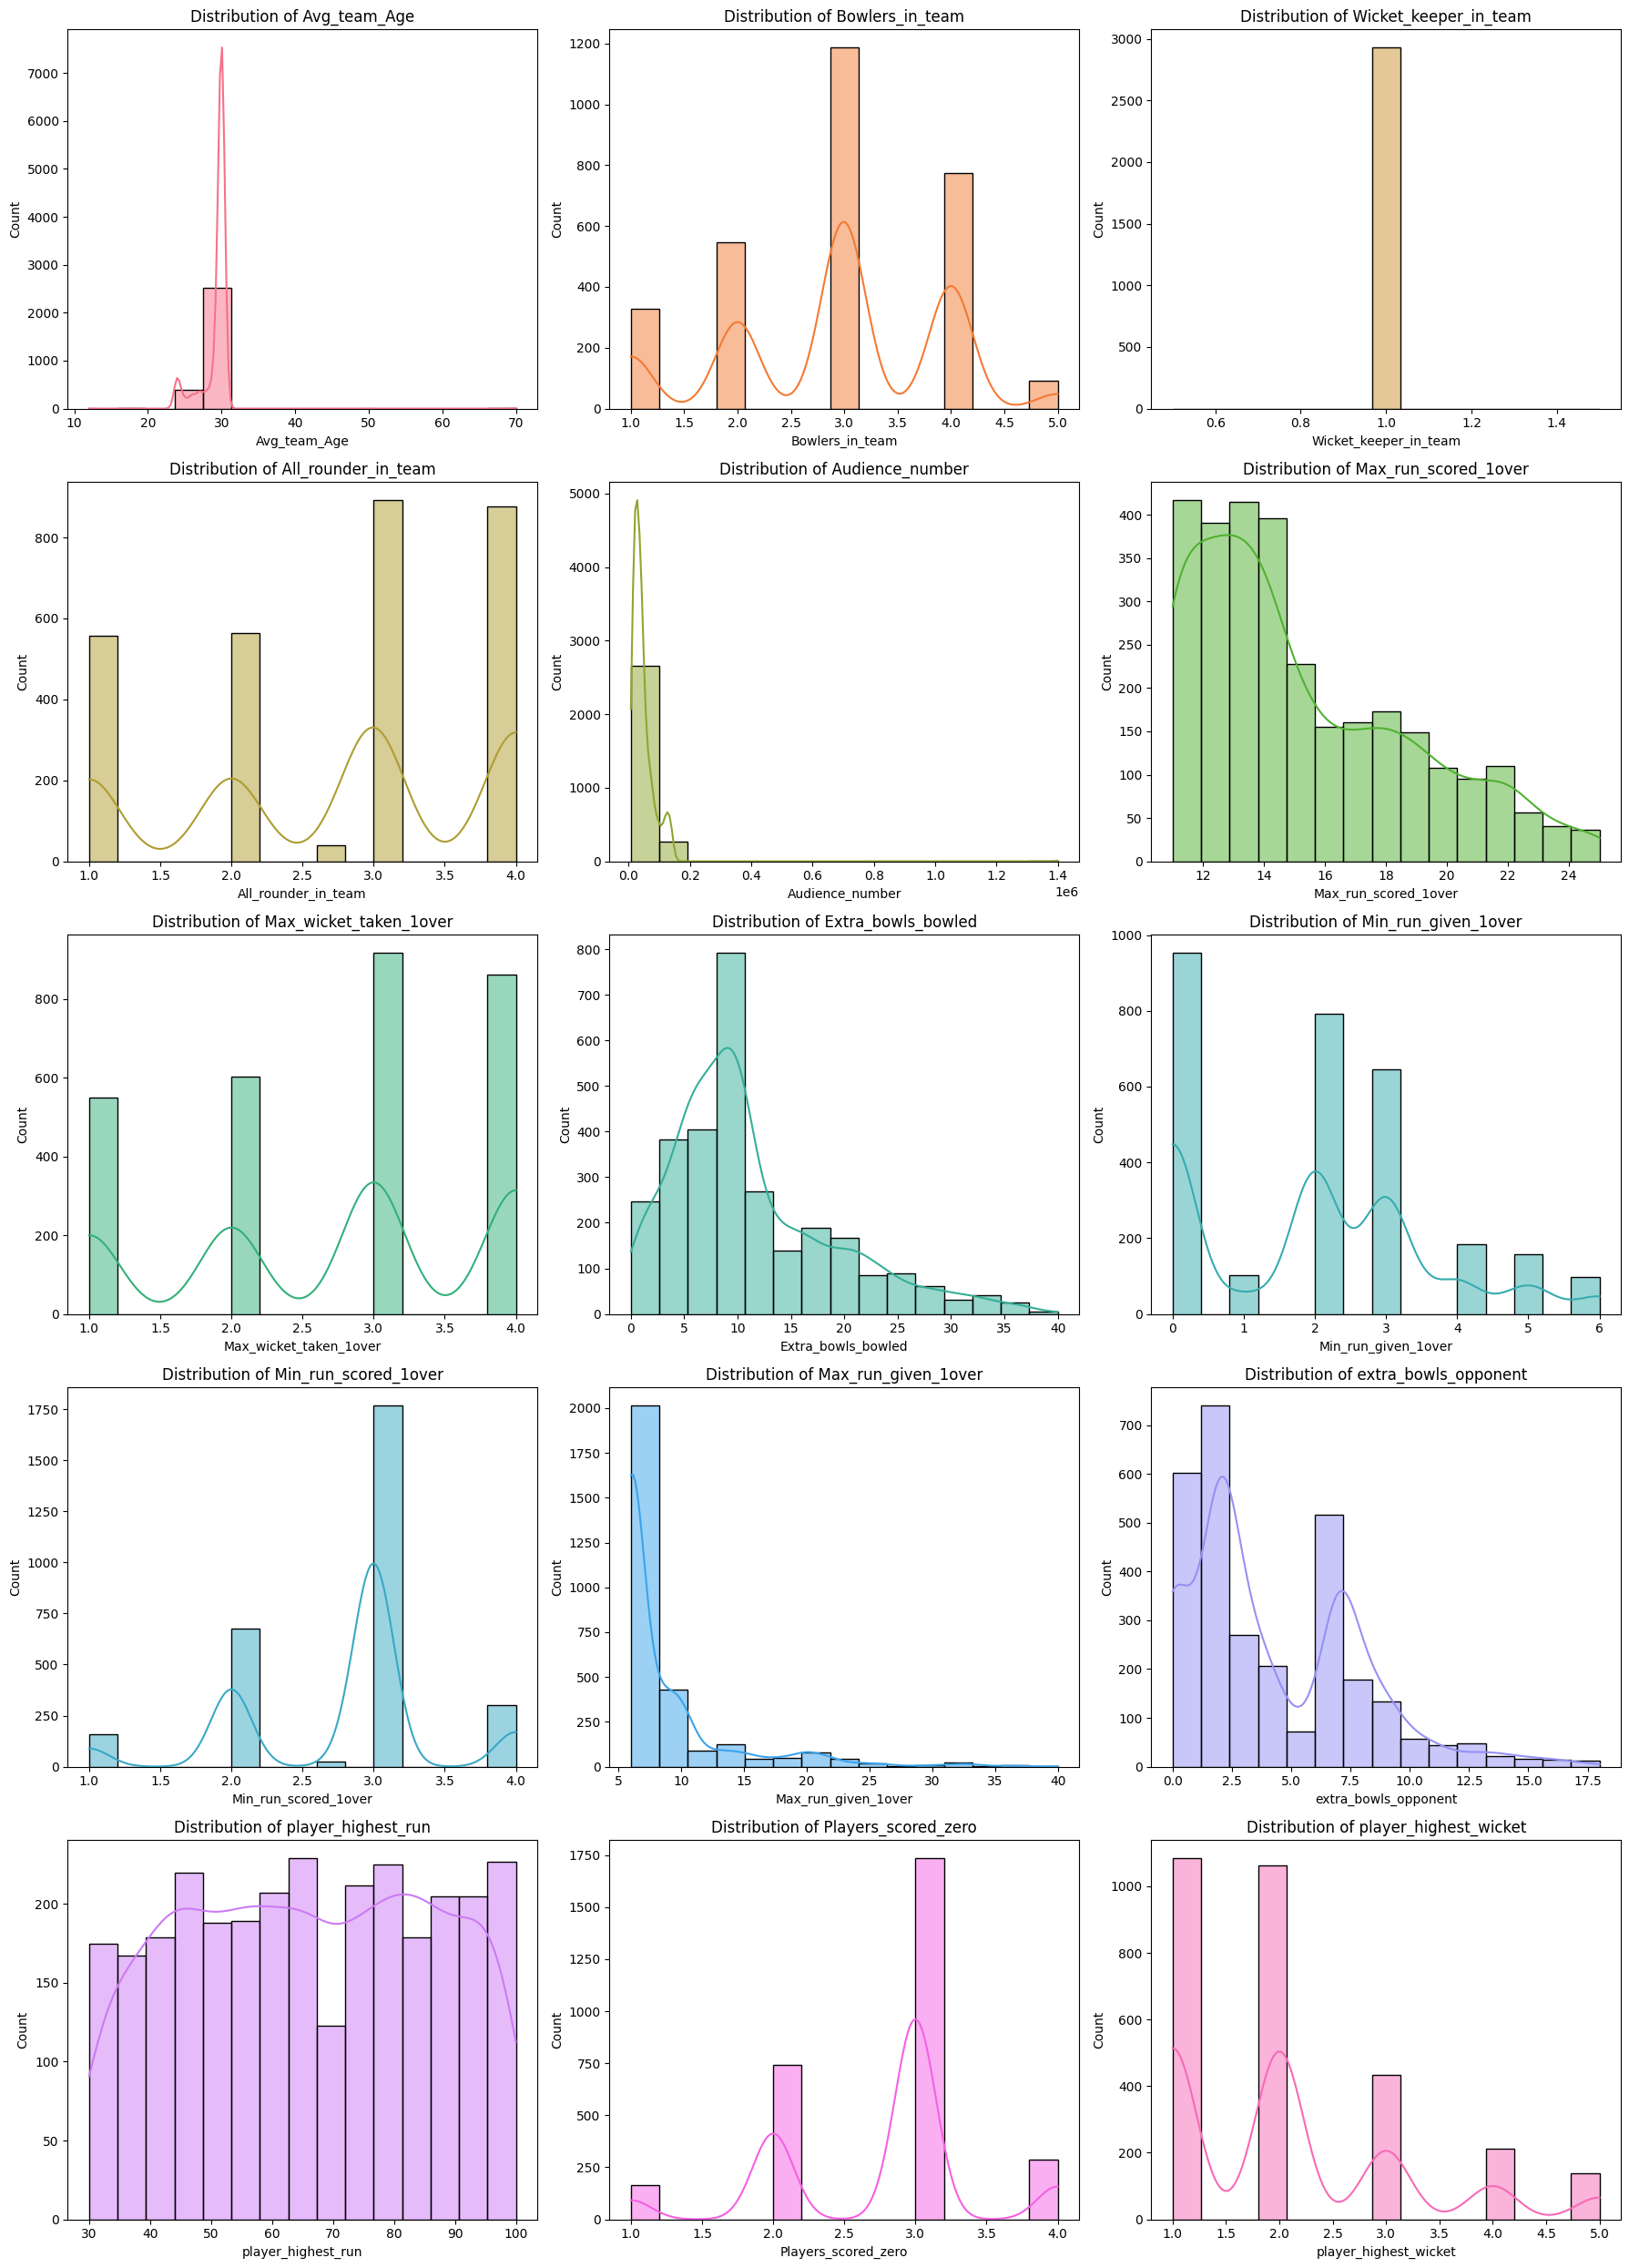

In [ ]:
# Define a custom color palette
colors = sns.color_palette("husl", len(num_cols))  # You can also try "Set2", "pastel", etc.

# Set number of plots per row
n_cols = 3
n_rows = (len(num_cols) + n_cols - 1) // n_cols  # Ensures enough rows

plt.figure(figsize=(18, 5 * n_rows))

# Plot each numeric column
for i, col in enumerate(num_cols):
    plt.subplot(n_rows, n_cols, i + 1)
    sns.histplot(data[col], kde=True, color=colors[i], bins=15)
    plt.title(f"Distribution of {col}")
    plt.xlabel(col)
    plt.ylabel("Count")

plt.tight_layout()
plt.show()


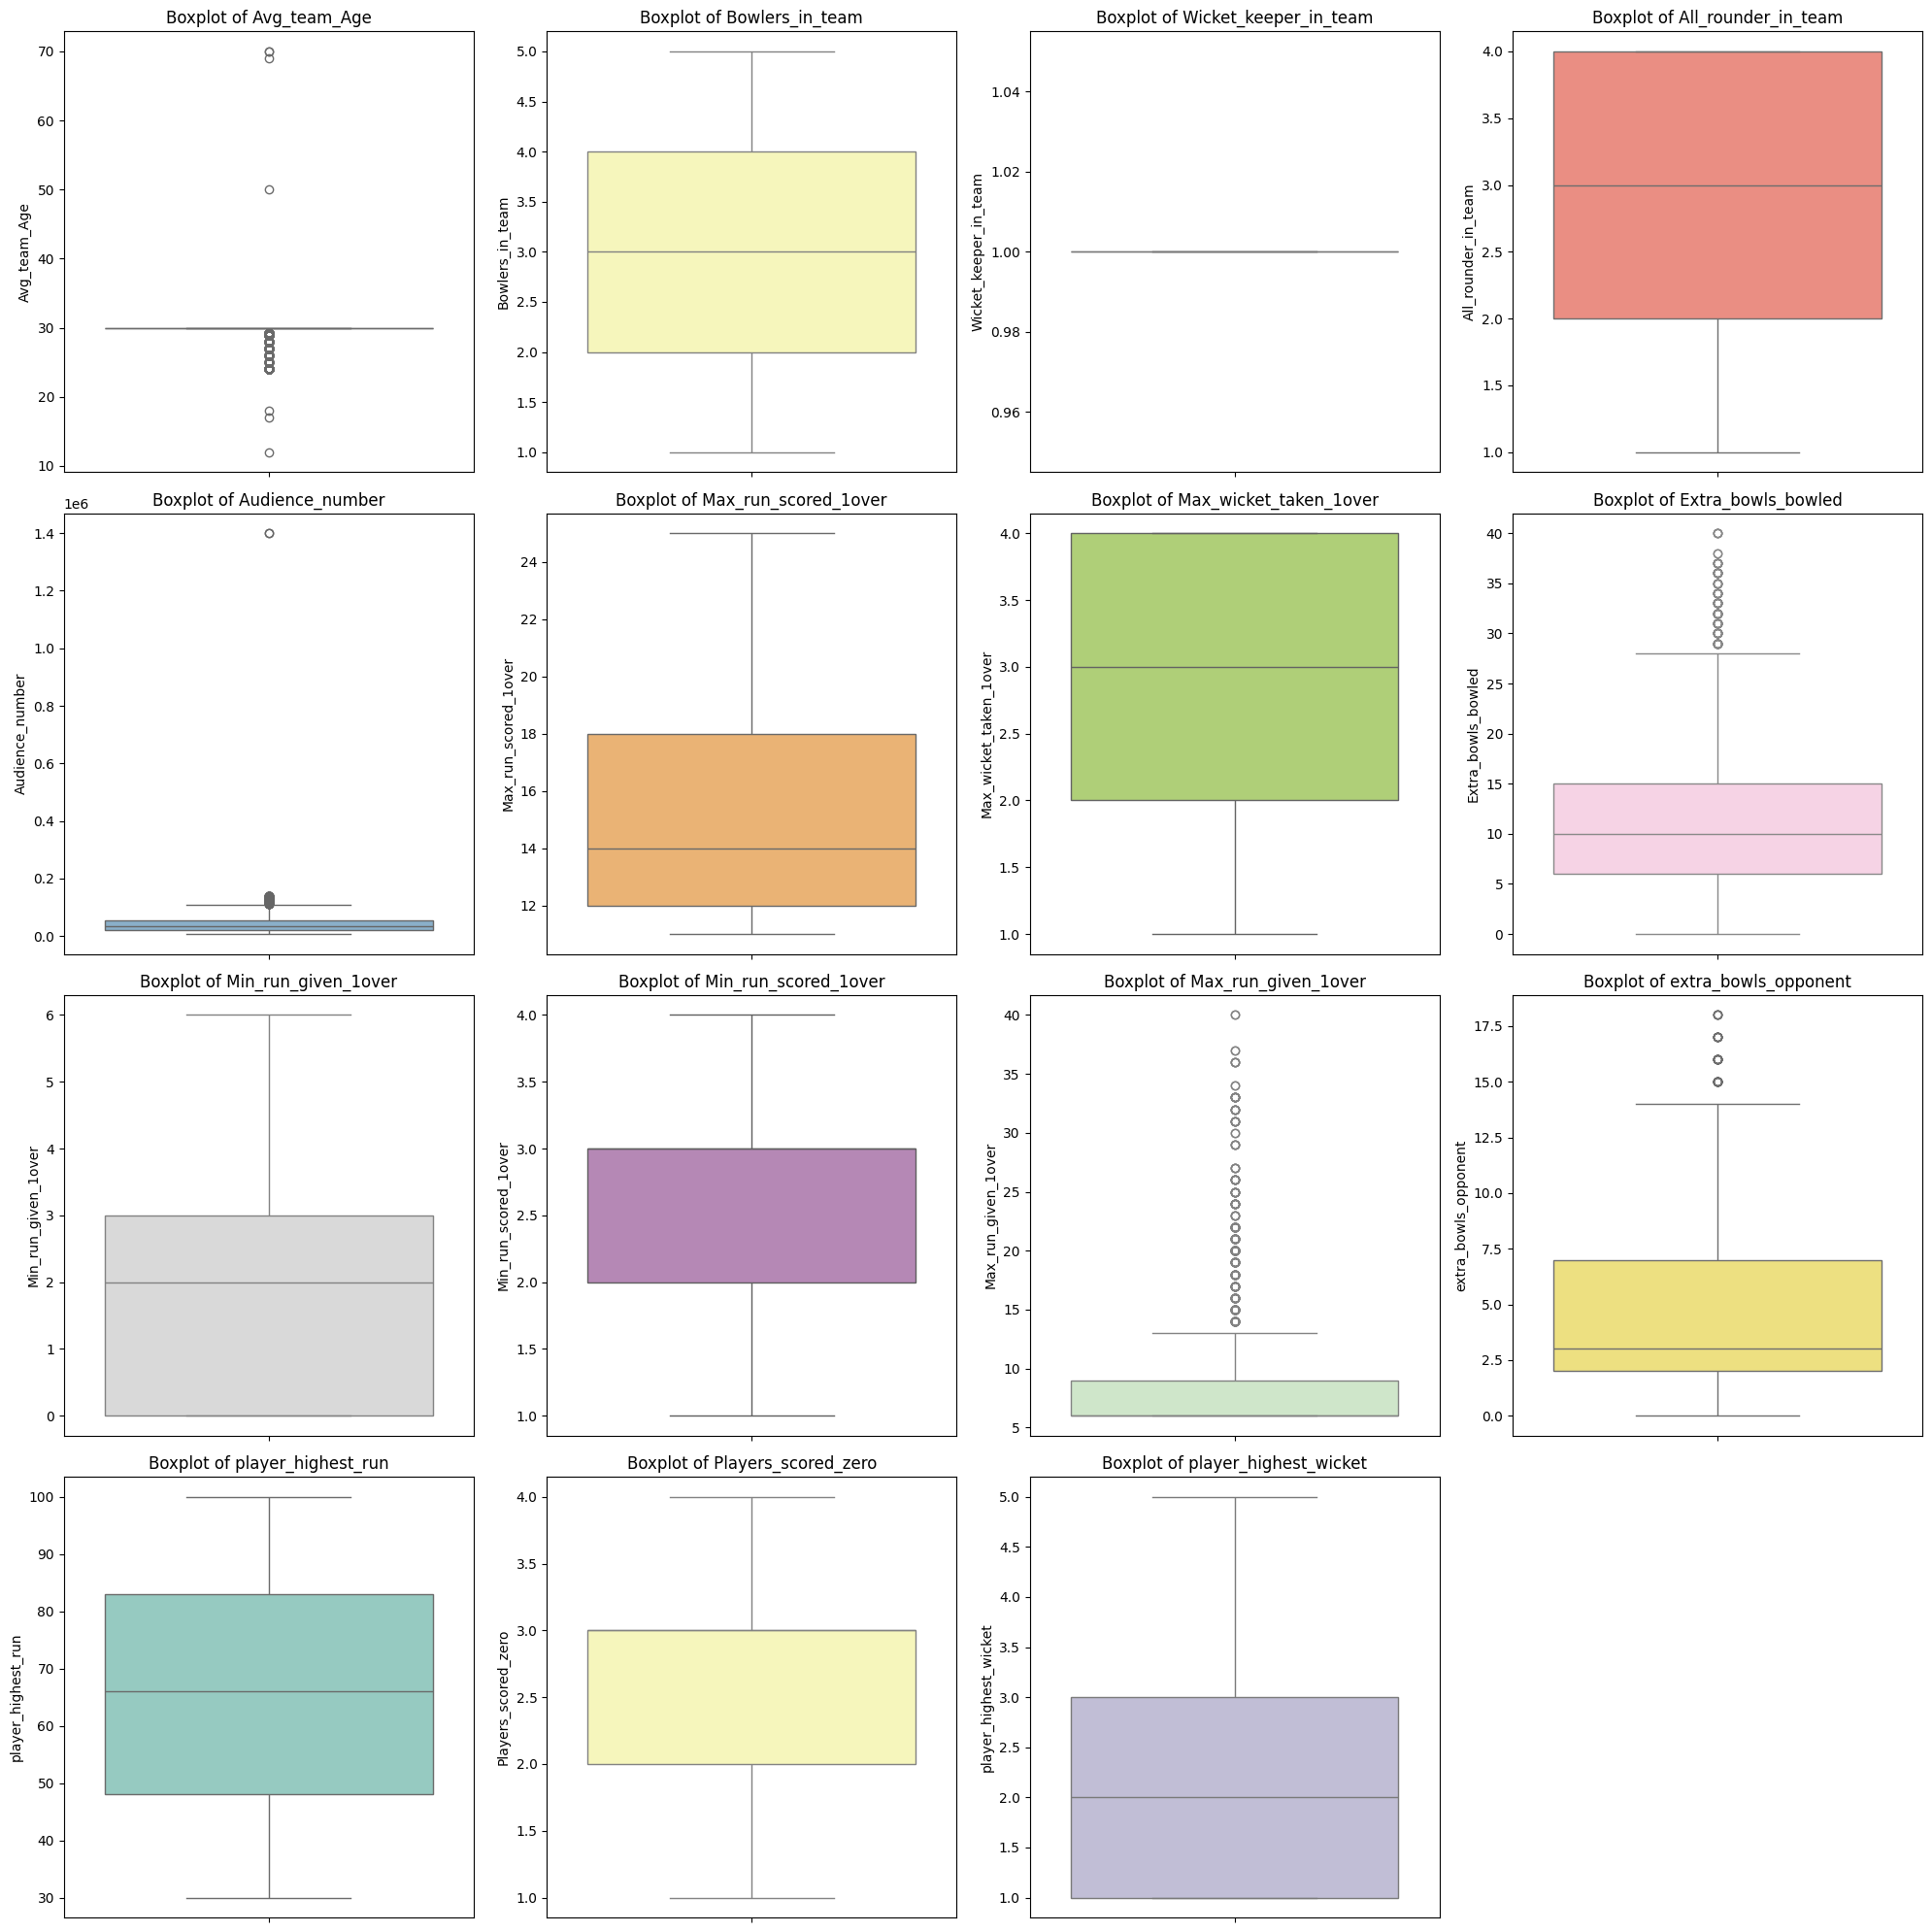

In [ ]:
# Define a color palette
colors = sns.color_palette("Set3", len(num_cols))  # Options: "pastel", "husl", "Set2"

# Set up plotting area with 4 subplots per row
n_cols = 4
n_rows = (len(num_cols) + n_cols - 1) // n_cols  # Ceiling division

plt.figure(figsize=(20, 5 * n_rows))  # Adjust figure width for 4 plots per row

# Plot each numeric column as a boxplot
for i, col in enumerate(num_cols):
    plt.subplot(n_rows, n_cols, i + 1)
    sns.boxplot(data=data, y=col, color=colors[i])
    plt.title(f"Boxplot of {col}")
    plt.ylabel(col)

plt.tight_layout()
plt.show()


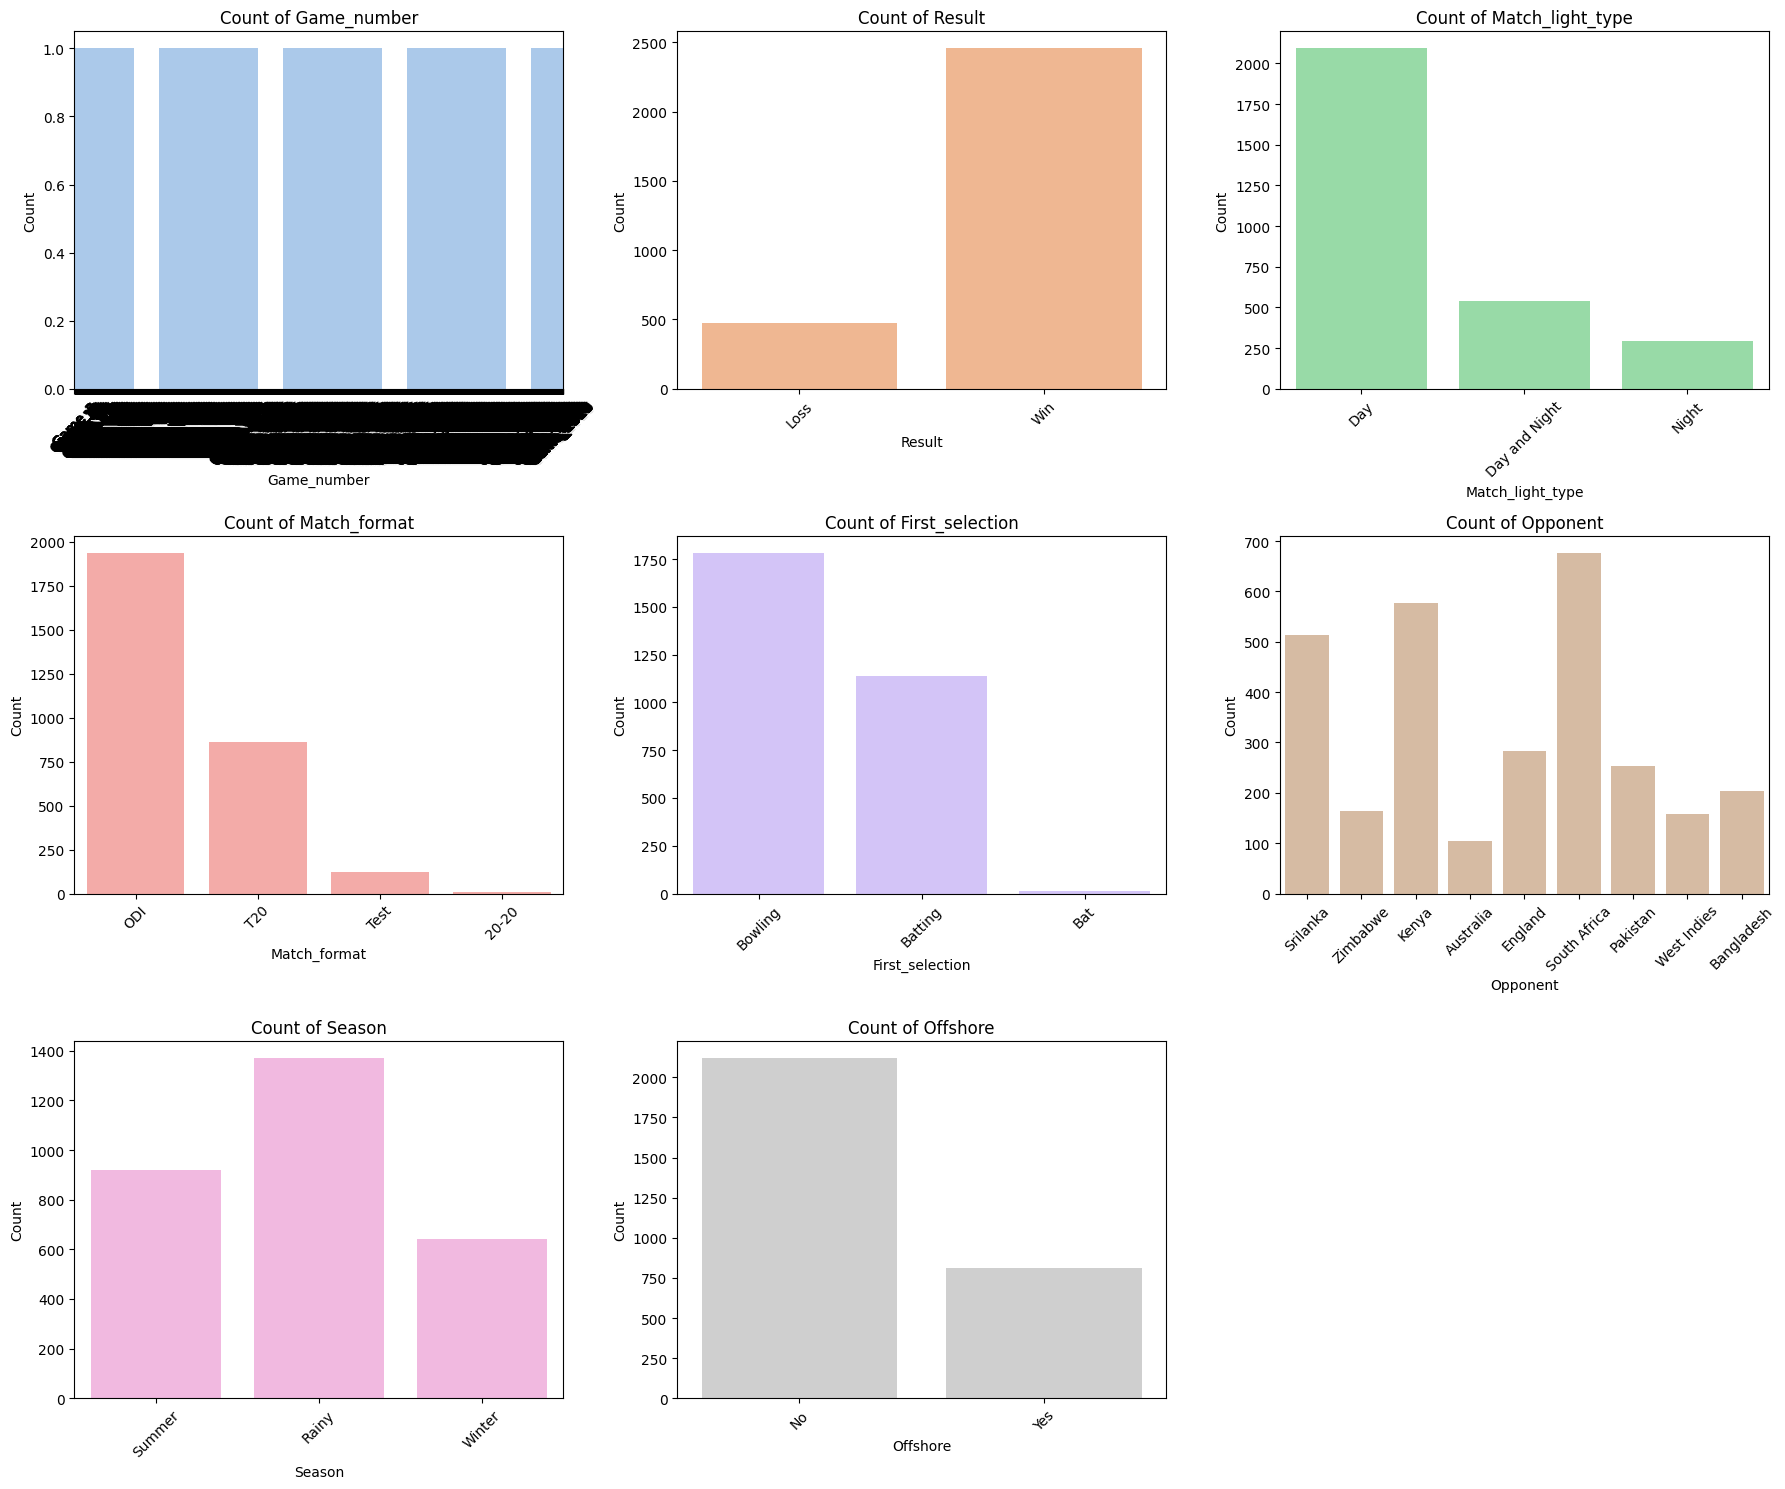

In [ ]:
# Select only categorical columns (object or category types)
cat_cols = data.select_dtypes(include=['object', 'category']).columns

# Define a color palette
colors = sns.color_palette("pastel", len(cat_cols))  # You can also try: "Set2", "husl", etc.

# Plot layout
n_cols = 3  # Number of plots per row
n_rows = (len(cat_cols) + 1) // n_cols

plt.figure(figsize=(18, 5 * n_rows))

# Create bar plots for each categorical variable
for i, col in enumerate(cat_cols):
    plt.subplot(n_rows, n_cols, i + 1)
    sns.countplot(data=data, x=col, color=colors[i])
    plt.title(f"Count of {col}")
    plt.xlabel(col)
    plt.ylabel("Count")
    plt.xticks(rotation=45)  # Rotate x-axis labels for readability

plt.tight_layout()
plt.show()


## Bivariate Analysis

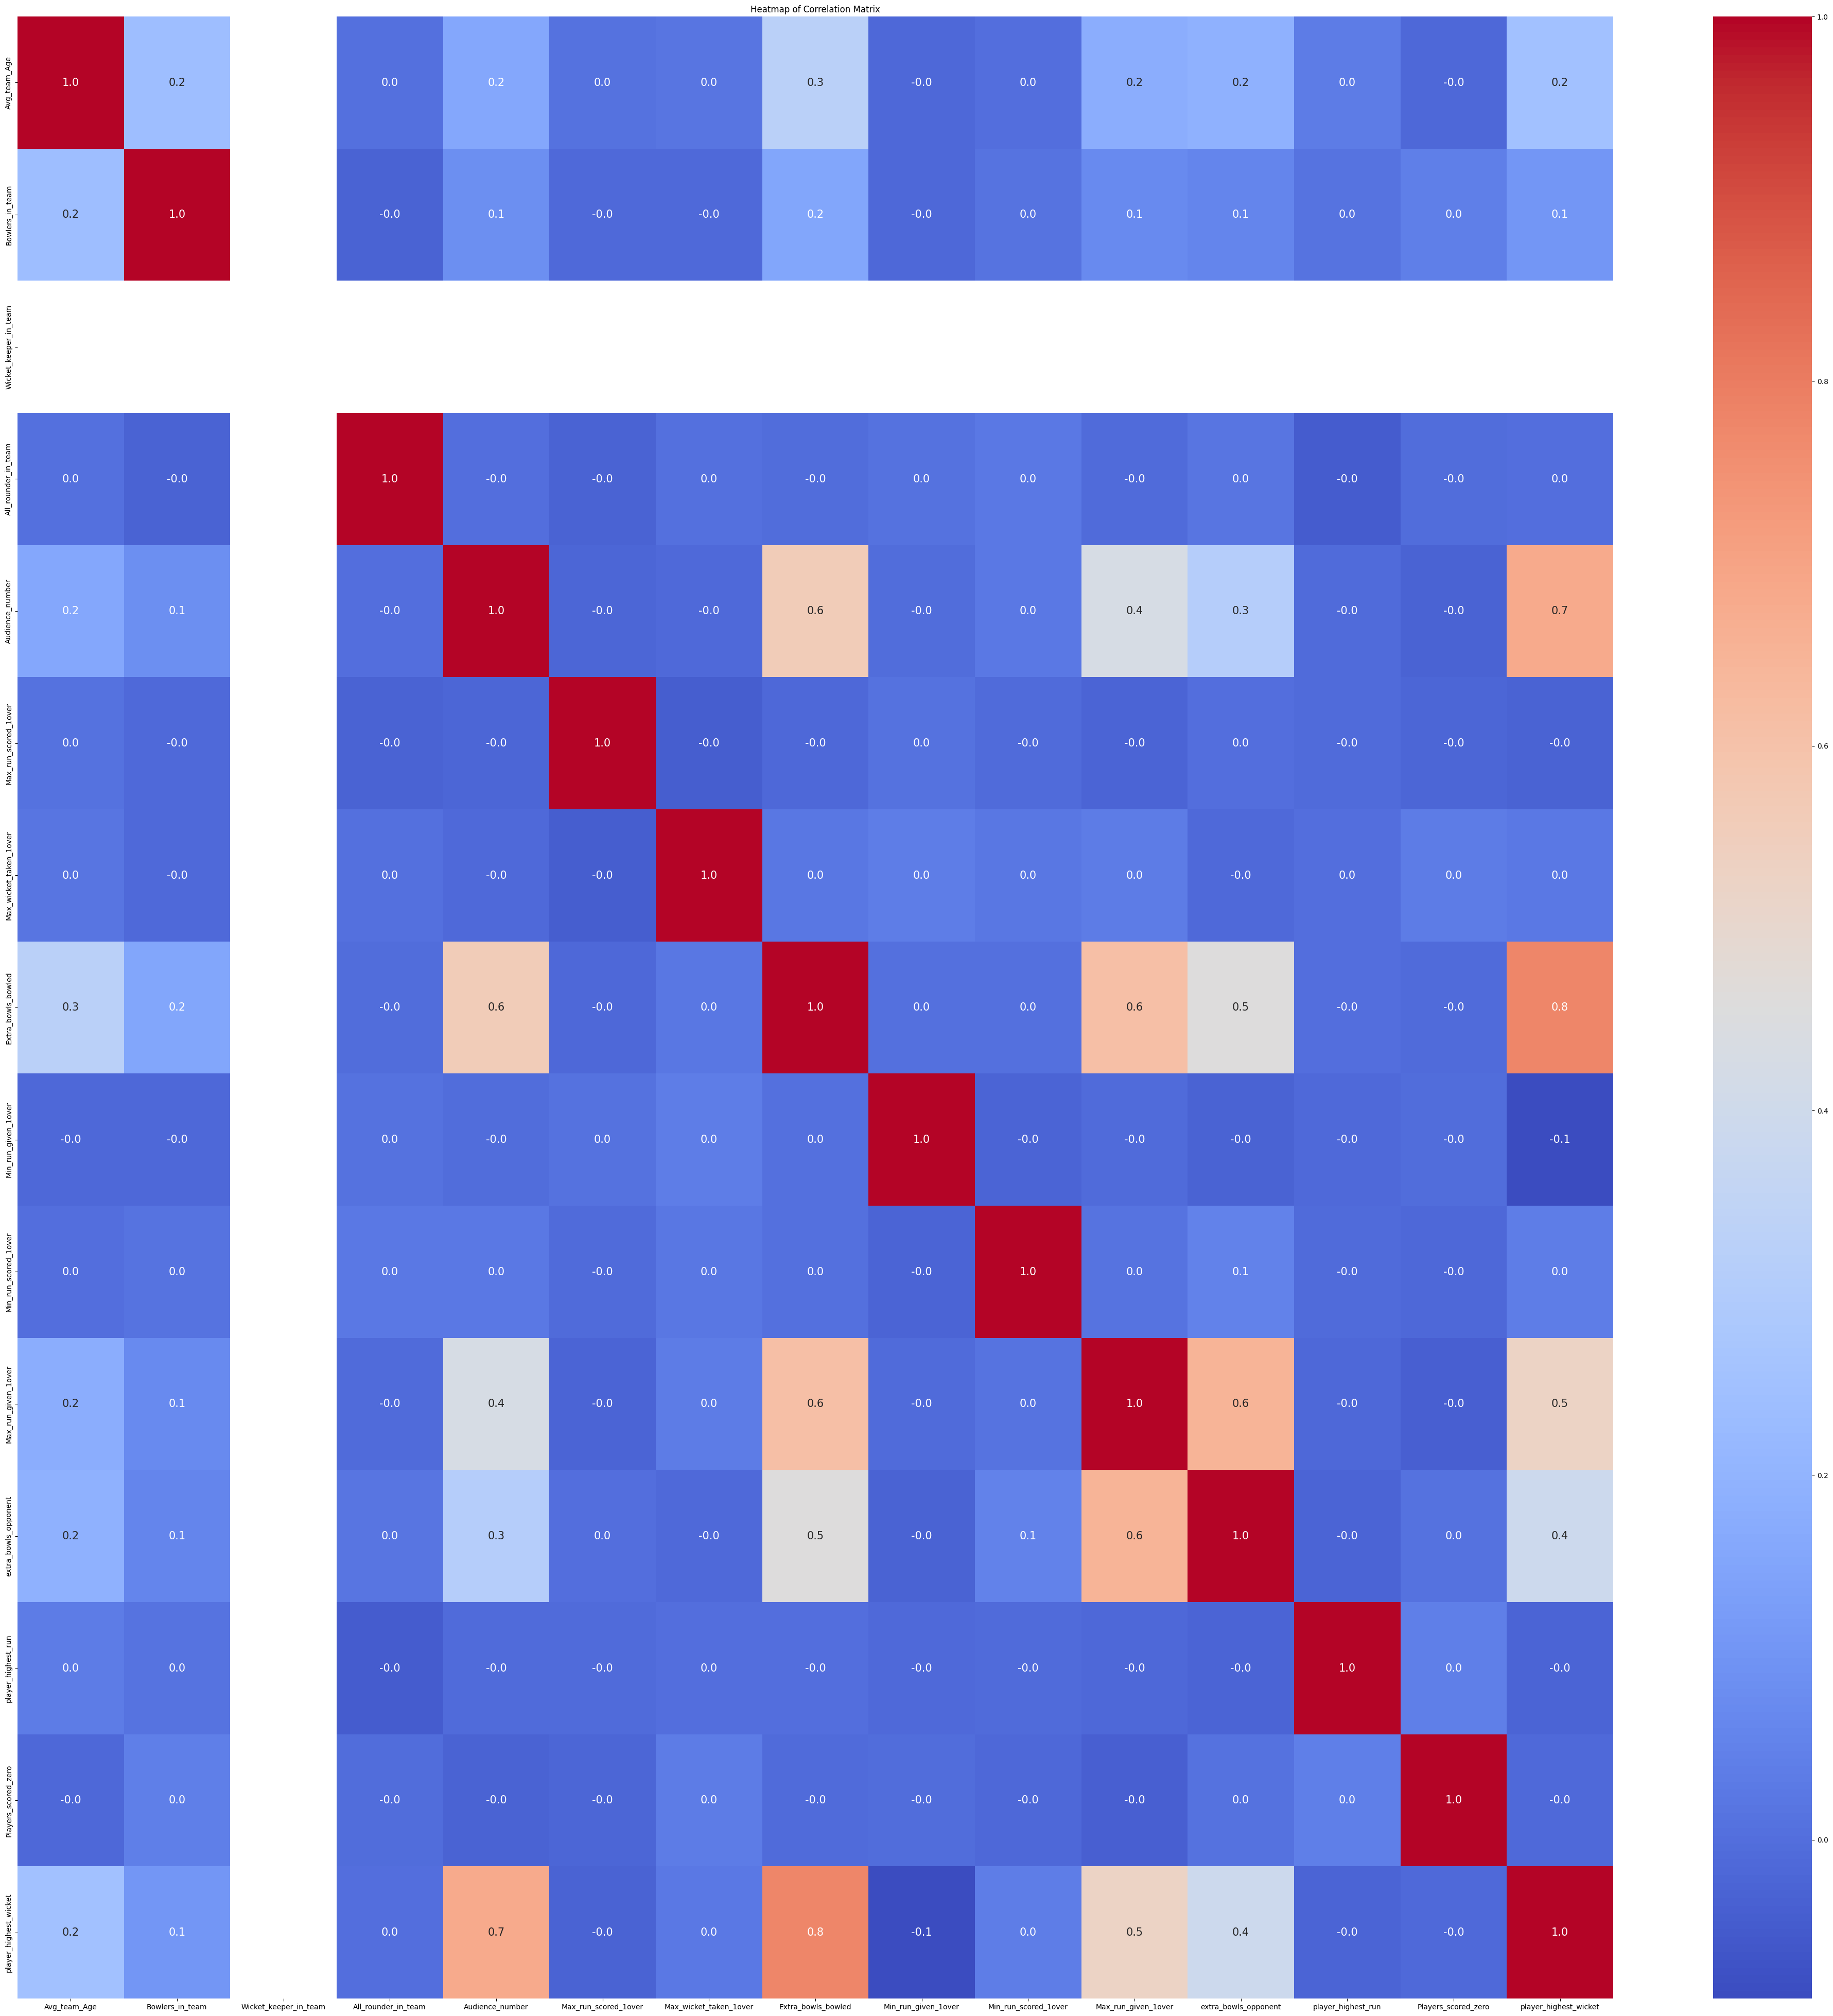

In [ ]:
# Calculate the correlation matrix
corr_matrix = data.corr(numeric_only=True)

# Create a heatmap of the correlation matrix
plt.figure(figsize=(50, 50))
sns.heatmap(corr_matrix, annot=True, cmap='coolwarm', fmt=".1f", annot_kws={"size": 15})
plt.title('Heatmap of Correlation Matrix')
plt.show()

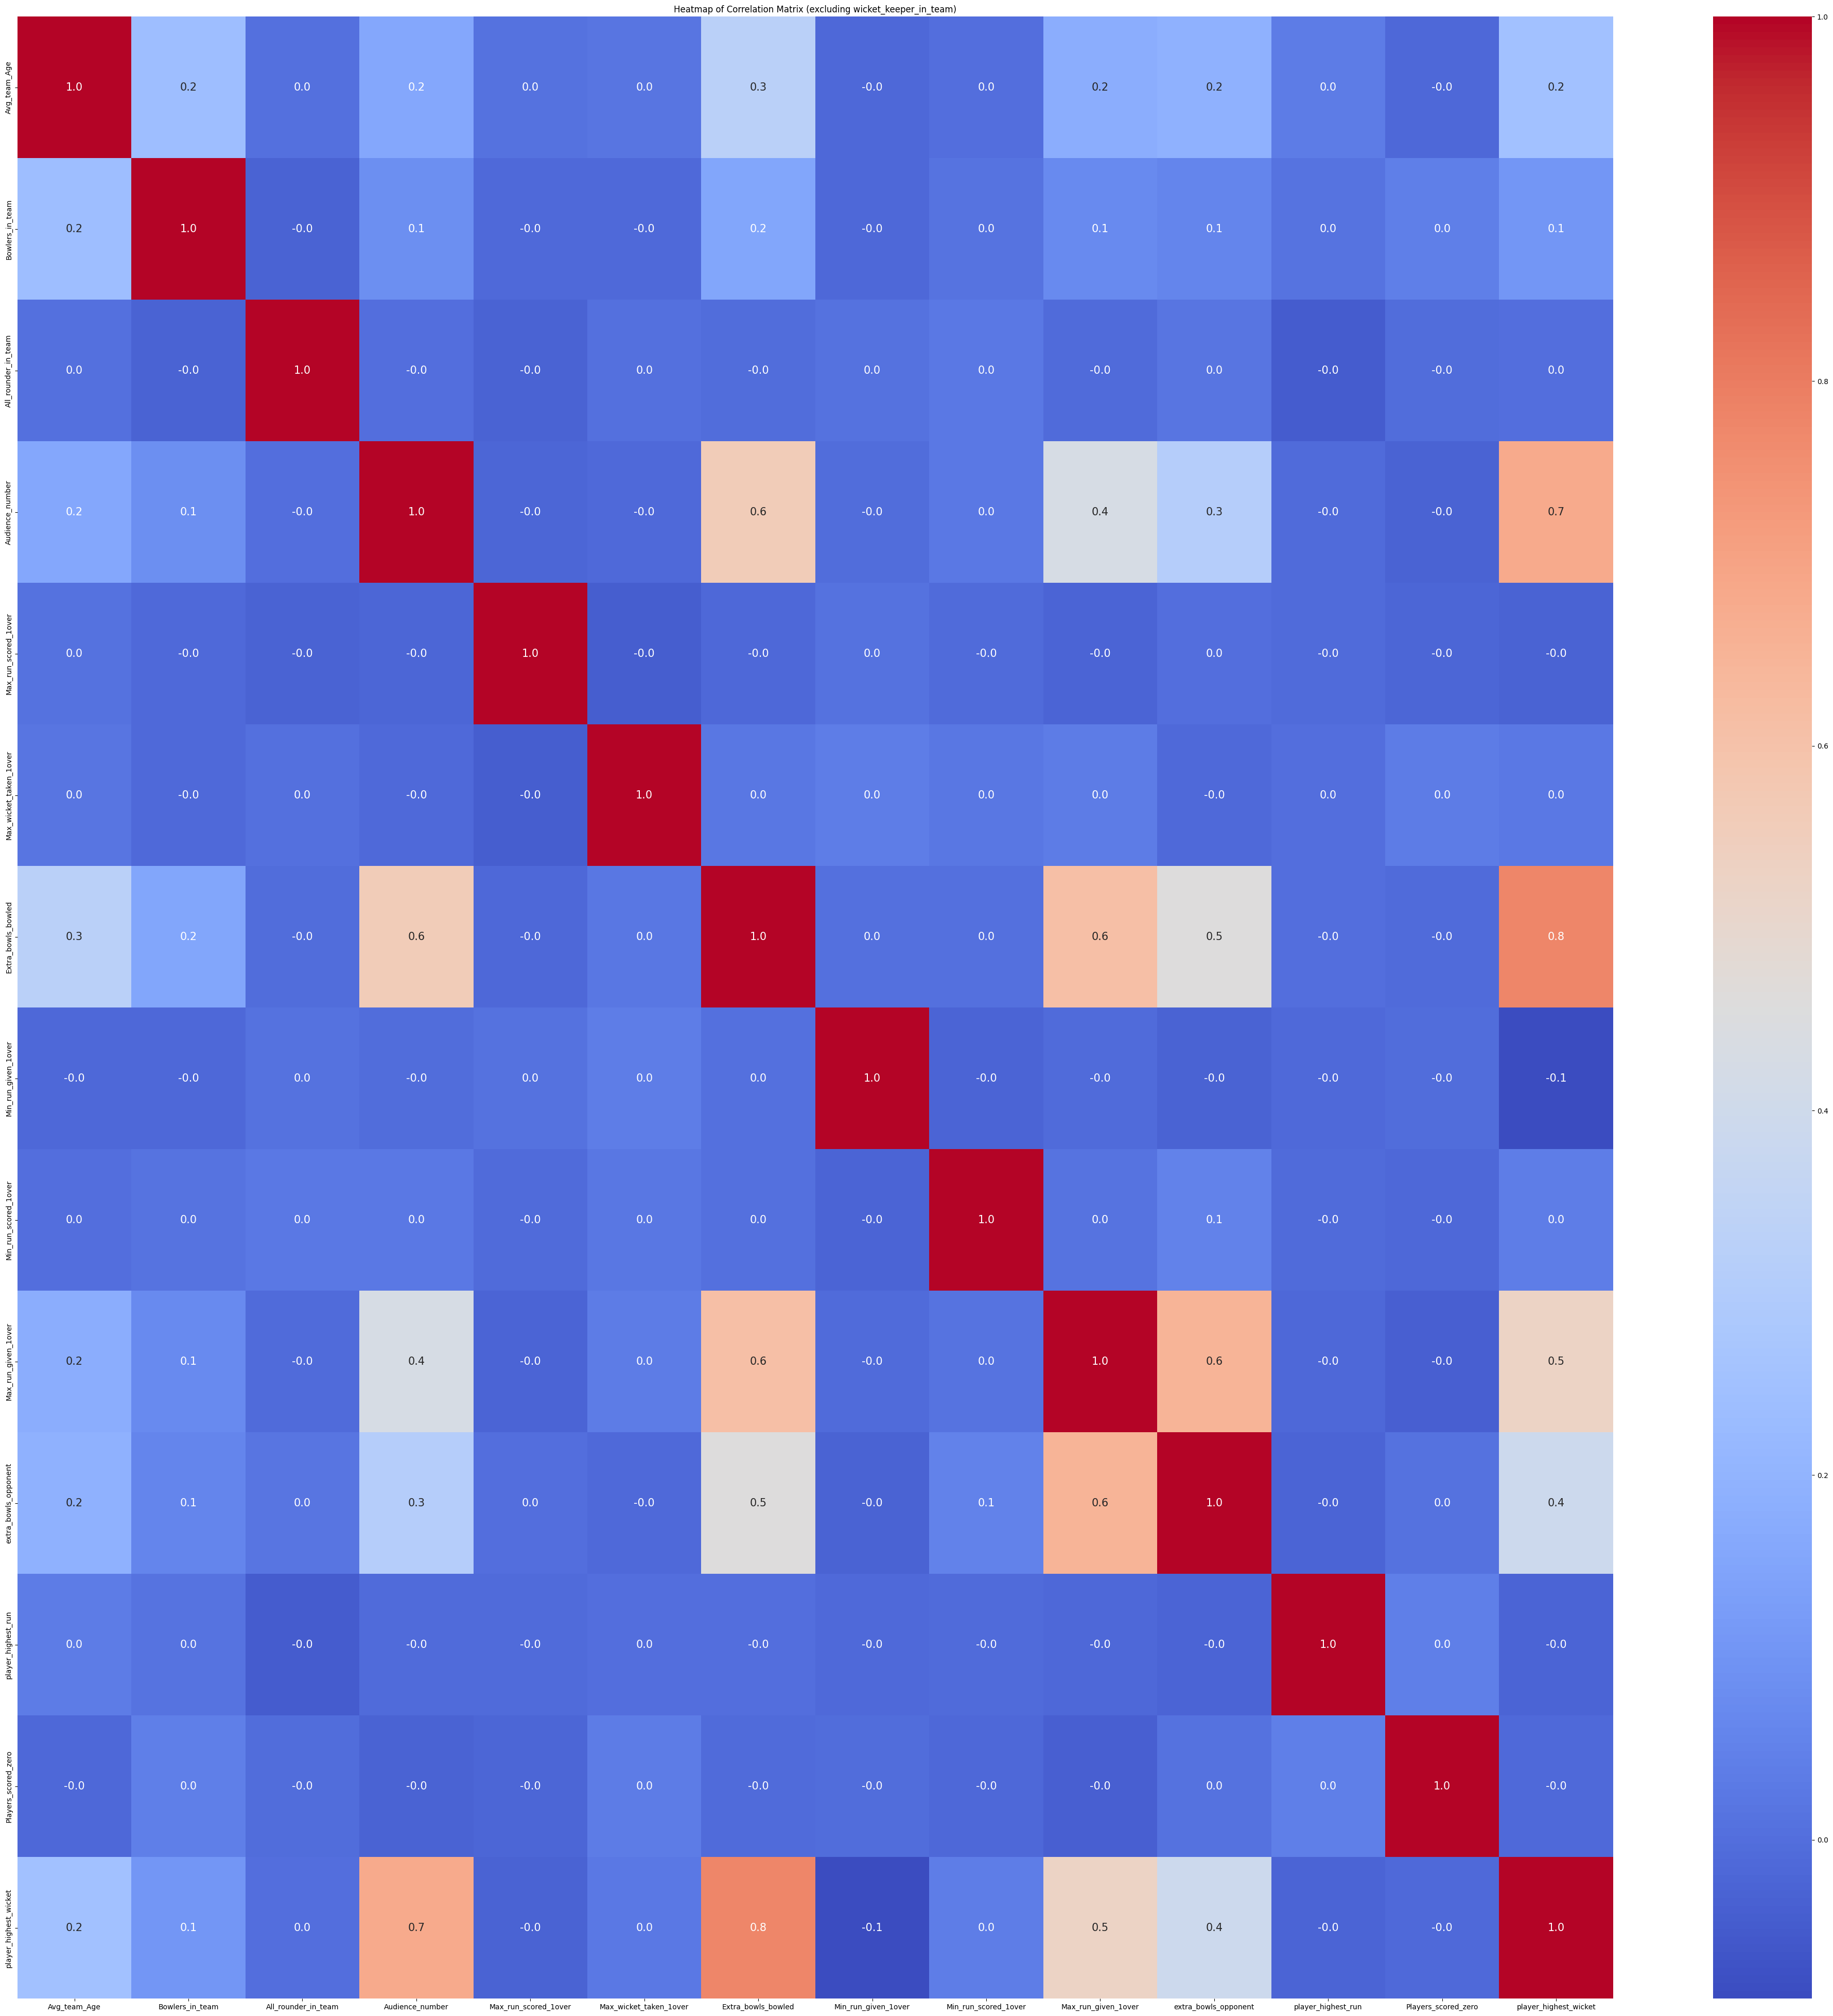

In [ ]:
# Exclude the 'wicket_keeper_in_team' column
cols_to_exclude = ['Wicket_keeper_in_team']
corr_matrix = data.drop(columns=cols_to_exclude).corr(numeric_only=True)

# Create a heatmap
plt.figure(figsize=(50, 50))
sns.heatmap(corr_matrix, annot=True, cmap='coolwarm', fmt=".1f", annot_kws={"size": 15})
plt.title('Heatmap of Correlation Matrix (excluding wicket_keeper_in_team)')
plt.show()

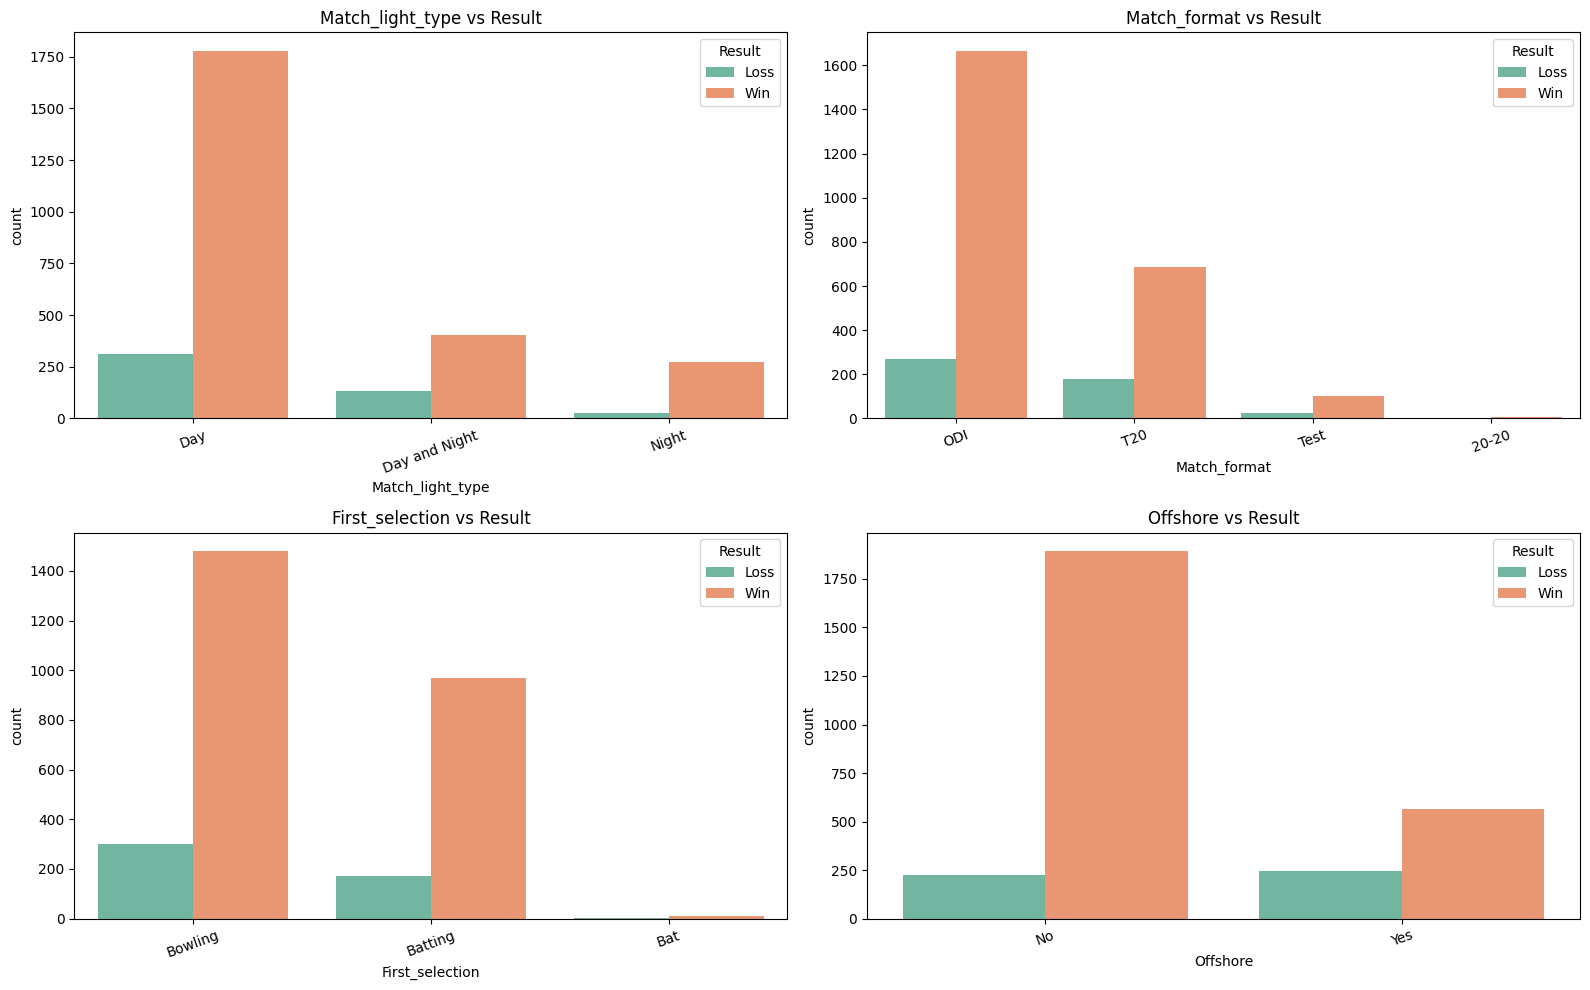

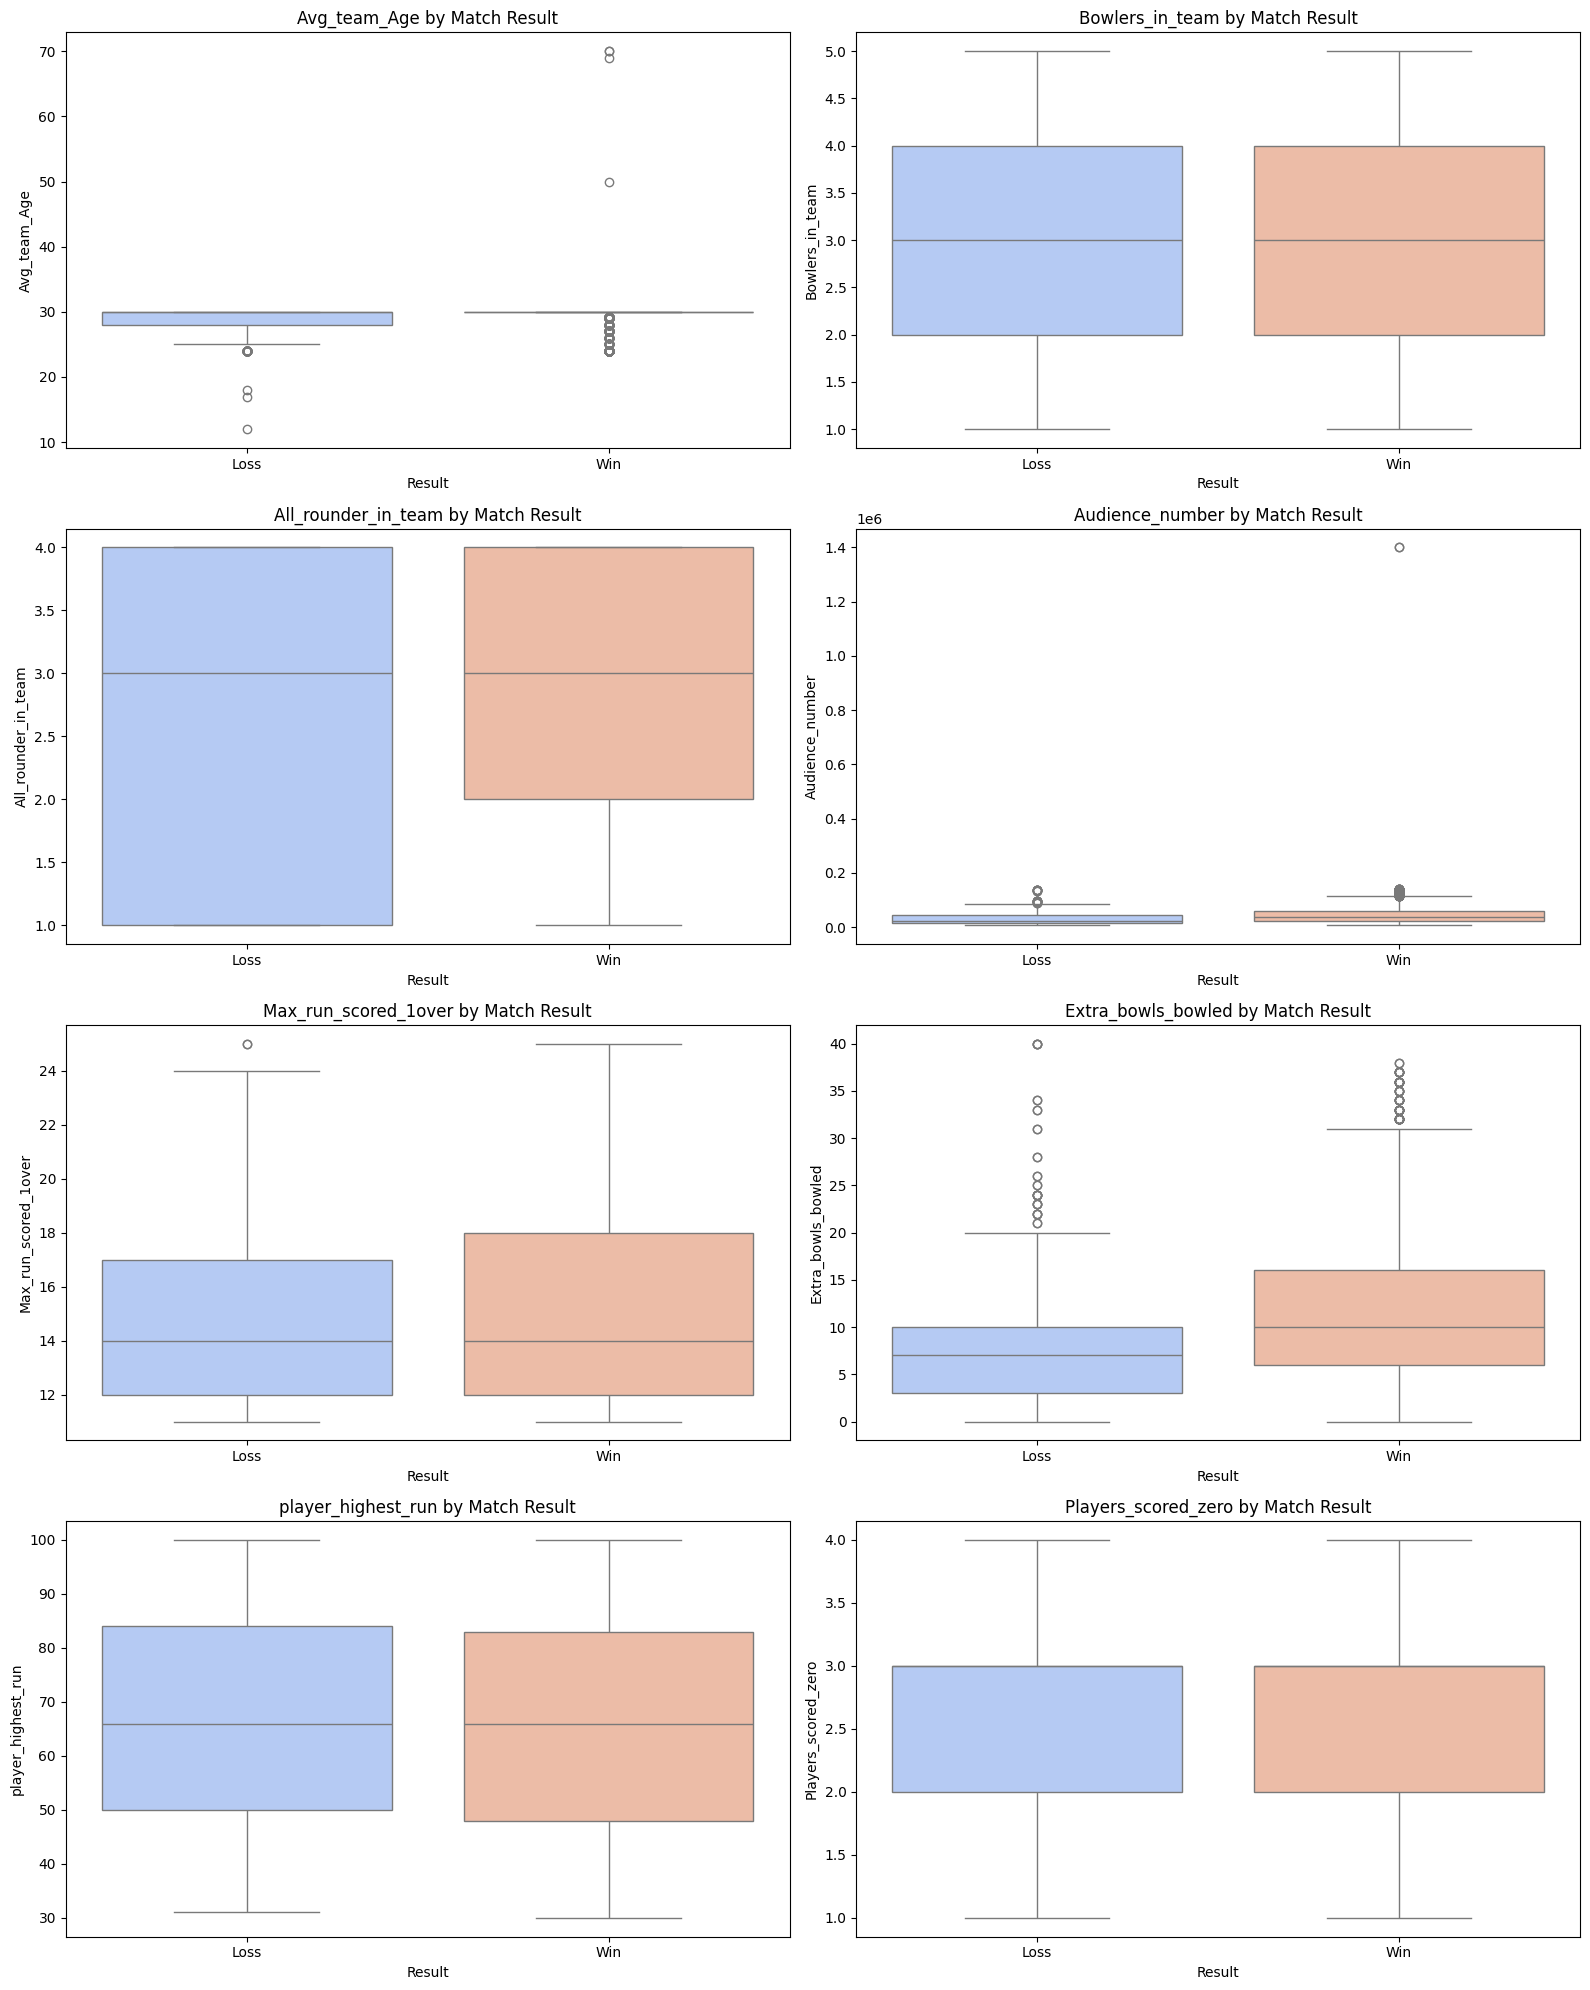

In [ ]:
# Bivariate Analysis: Relationship between categorical/numeric features and Result

# Select key categorical and numeric features to analyze against 'Result'
cat_vars = ["Match_light_type", "Match_format", "First_selection", "Offshore"]
num_vars = ["Avg_team_Age", "Bowlers_in_team", "All_rounder_in_team", "Audience_number",
            "Max_run_scored_1over", "Extra_bowls_bowled", "player_highest_run", "Players_scored_zero"]

# Plot categorical features vs Result
fig, axes = plt.subplots(2, 2, figsize=(16, 10))
axes = axes.flatten()

for i, col in enumerate(cat_vars):
    sns.countplot(data=data, x=col, hue="Result", ax=axes[i], palette='Set2')
    axes[i].set_title(f'{col} vs Result')
    axes[i].tick_params(axis='x', rotation=20)

plt.tight_layout()
plt.show()

# Box plots for numeric variables vs Result
fig, axes = plt.subplots(4, 2, figsize=(16, 20))
axes = axes.flatten()

for i, col in enumerate(num_vars):
    sns.boxplot(data=data, x="Result", y=col, ax=axes[i], palette='coolwarm')
    axes[i].set_title(f'{col} by Match Result')

plt.tight_layout()
plt.show()


**How does the Number of All-Rounders impact Maximum Runs in 1 Over?**

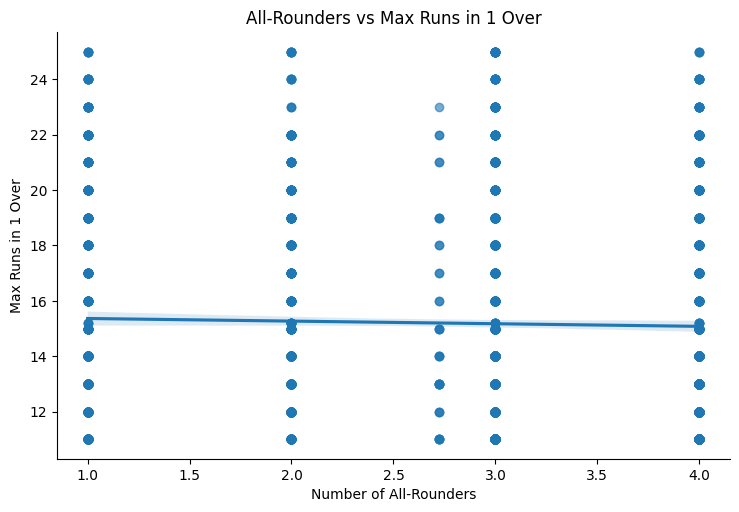

In [ ]:
sns.lmplot(data=data, x='All_rounder_in_team', y='Max_run_scored_1over', aspect=1.5, scatter_kws={'alpha':0.6})
plt.title("All-Rounders vs Max Runs in 1 Over")
plt.xlabel("Number of All-Rounders")
plt.ylabel("Max Runs in 1 Over")
plt.show()


•	The maximum runs in an over appear to be fairly consistent across all teams, regardless of whether they have 1 to 4 all-rounders.

•	The trend line is nearly flat, suggesting no significant correlation between the number of all-rounders and the maximum runs conceded in an over.

•	The spread of points shows that in all cases (from 1 to 4 all-rounders), teams have conceded between 11 and 25 runs in their worst over, indicating that the presence of more all-rounders does not necessarily reduce the chances of big overs.

•	This implies that the impact of all-rounders on preventing explosive overs is minimal, and teams may need to look at specialist bowlers or bowling strategies instead.


**Does Season affect Audience Attendance?**

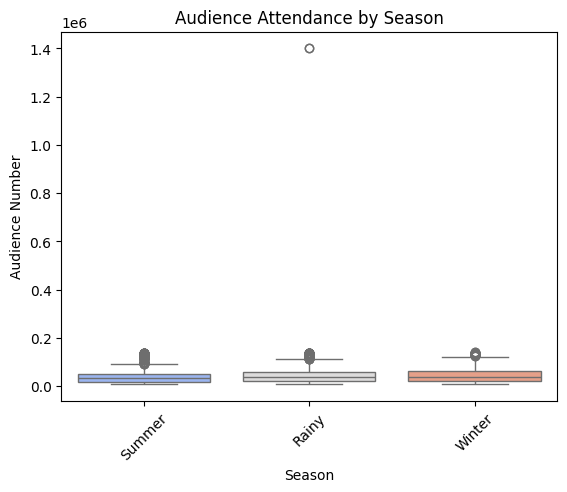

In [ ]:
sns.boxplot(data=data, x='Season', y='Audience_number', palette='coolwarm')
plt.title("Audience Attendance by Season")
plt.xlabel("Season")
plt.ylabel("Audience Number")
plt.xticks(rotation=45)
plt.show()


•	While the median audience attendance is relatively similar across Summer, Rainy, and Winter seasons, Rainy season shows a significant outlier, with one match exceeding 1.4 million in attendance.

•	Most matches in all seasons maintain similar interquartile ranges, but Rainy season appears to have the most variation in audience numbers.


**Does Number of Bowlers in the Team Affect Runs Conceded in a Single Over?**

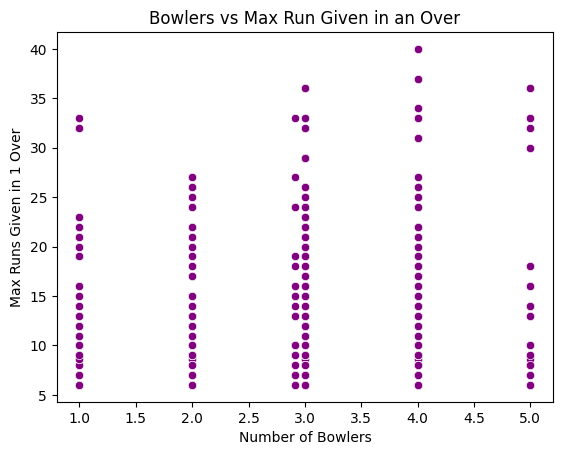

In [ ]:
sns.scatterplot(data=data, x='Bowlers_in_team', y='Max_run_given_1over', color='purple')
plt.title("Bowlers vs Max Run Given in an Over")
plt.xlabel("Number of Bowlers")
plt.ylabel("Max Runs Given in 1 Over")
plt.show()


•	Maximum runs in an over peaked more frequently when 3 or 4 bowlers were used.

•	When only 1 or 2 bowlers were used, maximum runs given in an over remained relatively lower.

•	This could suggest that teams using a higher rotation of bowlers may expose weaker links, leading to big overs.


**Is Average Team Age Associated with Number of Players Scoring Zero?**

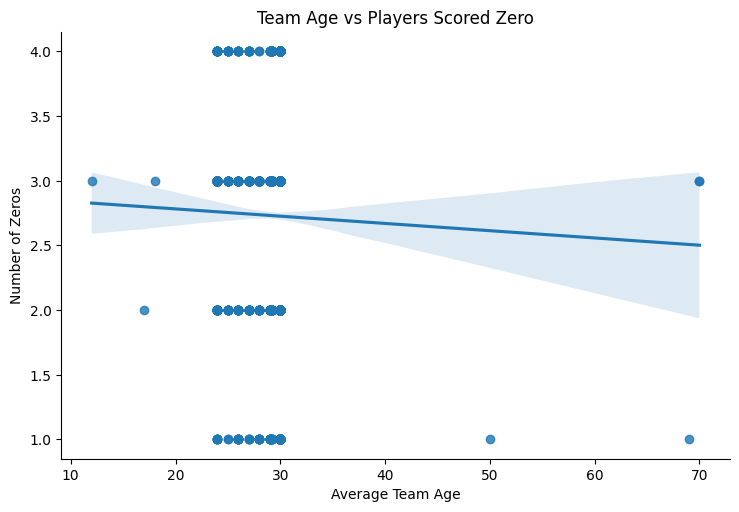

In [ ]:
sns.lmplot(data=data, x='Avg_team_Age', y='Players_scored_zero', aspect=1.5)
plt.title("Team Age vs Players Scored Zero")
plt.xlabel("Average Team Age")
plt.ylabel("Number of Zeros")
plt.show()


•	There’s a slight negative trend, indicating that younger teams may have more players scoring zero.

•	Older teams seem slightly more consistent, with fewer players getting out on zero.

•	However, the relationship is not very strong, as there's a wide spread of data at various ages.


**Does Number of All-Rounders Affect Extras Bowled?**

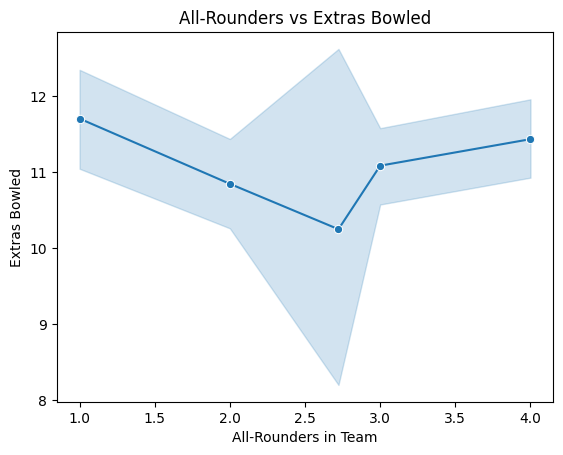

In [ ]:
sns.lineplot(data=data, x='All_rounder_in_team', y='Extra_bowls_bowled', marker='o')
plt.title("All-Rounders vs Extras Bowled")
plt.xlabel("All-Rounders in Team")
plt.ylabel("Extras Bowled")
plt.show()


•	Teams with more all-rounders tend to bowl fewer extras, with the lowest average extras bowled seen when there are 3 all-rounders.

•	However, variability increases beyond 2 all-rounders, indicating inconsistency.

•	This suggests a balanced number of all-rounders may contribute to bowling discipline.


**Does Match Light Type Influence Maximum Runs Scored in 1 Over?**

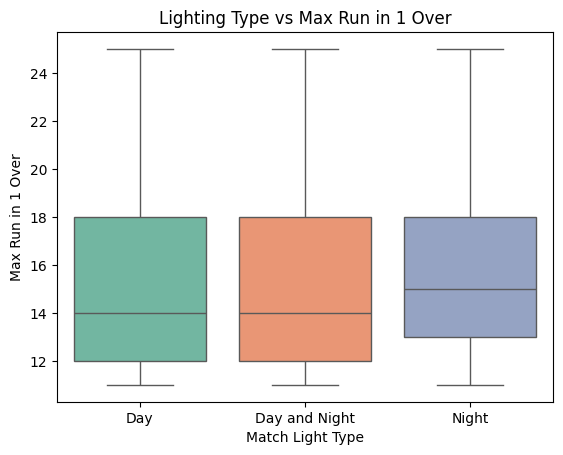

In [ ]:
sns.boxplot(data=data, x='Match_light_type', y='Max_run_scored_1over', palette='Set2')
plt.title("Lighting Type vs Max Run in 1 Over")
plt.xlabel("Match Light Type")
plt.ylabel("Max Run in 1 Over")
plt.show()


•	Night matches show slightly higher median values and upper whiskers, suggesting more explosive overs are likely.

•	However, all three categories (Day, Day-Night, Night) show similar ranges, with a max cap around 25 runs per over.

•	Night conditions may give batsmen a slight edge, possibly due to dew or better pitch conditions under lights.


## EDA - Insights

Team Composition & Performance

•	Teams with 3–4 full-time bowlers and at least 2 all-rounders tend to win more often, indicating a balanced strategy is crucial.
•	Teams with younger average player age (below ~30 years) had a slightly better win ratio, suggesting agility and stamina play roles in match success.
•	The number of players scoring zero (ducks) is higher in losing teams, highlighting the importance of a strong top and middle order.

Match Conditions & Format
•	Day & Night matches have a higher win rate, likely due to improved visibility and cooler conditions.
•	T20 and ODI formats show better win rates than Test matches, possibly due to different strategies and game pacing.
•	Batting first slightly favors the outcome, possibly due to better pitch conditions early on or scoreboard pressure on opponents.

Location & Audience
•	Home matches show a significantly higher win percentage, reinforcing the home advantage and crowd support theory.
•	Higher audience numbers correlate with match wins, suggesting performance uplift in front of larger crowds.

Performance Metrics
•	Teams that win tend to:
o	Score more runs in at least one over (e.g., 20+ runs).
o	Have a top player scoring above 75+ in the match.
o	Bowl fewer extras, indicating discipline and precision.







# **Business Recommendations**

1.	Team Selection Strategy

* Encourage selection of at least 2 all-rounders for lineup flexibility.
* Maintain a balance of 3–4 bowlers and a fixed wicketkeeper per team.
* Promote rotation of younger players into the playing XI for added agility.

2.	Match Preparation & Venue Strategy

* Focus on securing home games and training in home-like conditions when playing offshore.
* Leverage Day & Night match formats where performance is historically stronger.

3.	Fan Engagement & Marketing

* Capitalize on matches with higher audience turnout to promote merchandise, advertising, and player branding.
* Use player data (e.g., top scorers and wicket-takers) to personalize marketing campaigns.

4.	Performance Monitoring & Training

* Prioritize training to minimize extras and improve consistency in death overs.
* Analyze opposition bowling trends to prepare batsmen for high-scoring over opportunities.


#**Conclusion**

The analysis highlights that match outcomes are influenced by a blend of player skill, team structure, match conditions, and discipline. A winning team is typically young, balanced, plays fewer extras, leverages home advantage, and features standout individual performances. These insights can be directly translated into strategic decisions around team selection, match preparation, fan engagement, and game tactics, ultimately driving better match outcomes and commercial success.